In [1]:
%load_ext autoreload
%autoreload 2

import sys, warnings, glob, datetime
import xwmt, xwmb, xgcm, regionate, xbudget
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import seaborn as sns
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm

dpi = 150
mpl.rcParams['figure.dpi'] = dpi

sys.path.insert(0, '/user/anthony.meza/CM4XAbyssalSWMT/src')
from src import *
sns.set_theme(context='notebook', style='ticks')

In [2]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/user/anthony.meza/CM4XAbyssalSWMT/notebooks/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='scavenger',
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=16)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /user/anthony.meza/CM4XAbyssalSWMT/notebooks/logs/dask-worker-%J.err
#SBATCH -o /user/anthony.meza/CM4XAbyssalSWMT/notebooks/logs/dask-worker-%J.out
#SBATCH -p scavenger
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/user/anthony.meza/miniforge3/envs/cm4x_chapter2/bin/python -m distributed.cli.dask_worker tcp://10.151.1.152:38447 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.151.1.152:38447,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


2026-07-01 22:56:45,530 - tornado.application - ERROR - Uncaught exception GET /individual-task-stream/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:9253', method='GET', uri='/individual-task-stream/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/tornado/web.py", line 3409, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a lar

In [3]:
   
daterange2tuple = lambda x: tuple(map(int, x.split('-')))

In [4]:
SWMT_var_to_label = {
    # heat budget
    "SWMT":             "net surface transformation",

    "SWMT_heat":             "heat",
    "SWMT_heat_latent":      "latent heat",
    "SWMT_heat_frazil":      "frazil",
    "SWMT_heat_longwave":    "longwave",
    "SWMT_heat_shortwave":   "shortwave heat",
    "SWMT_heat_mass_transfer":"mass transfer",
    "SWMT_heat_sensible":    "sensible heat",
    "SWMT_salt_residual":    "salt residual",
    "SWMT_residual":    "residual",

    # salt budget
    "SWMT_salt":             "salt",
    "SWMT_salt_evaporation": "evap",
    "SWMT_salt_precipitation":"precip",
    "SWMT_salt_rivers":      "rivers",
    "SWMT_salt_icebergs":    "icebergs",
    "SWMT_salt_basal_salt":  "basal salt",
    "SWMT_salt_sea_ice":     "sea-ice freeze/melt",
    "SWMT_heat_residual":    "heat residual",
    "SWMT_salt_precip_minus_evaporation": "precip/evap",
    "other_terms": "other terms"

}

### Load in data

In [5]:
expt_colors = dict(); expt_colors["control"] = "#2f74b3"; expt_colors["forced"] = "#cc415a"

In [6]:
ds = xr.open_dataset(outputdir("Southern_Ocean_DSW_1000m_WMT_Budget.zarr"), engine = "zarr")
ds_monthly_SWMT = get_SWMT(ds)

ds = ds.groupby("time.year").mean("time")
ds_SWMT = get_SWMT(ds)
ds["surface_boundary_fluxes"] = ds["boundary_fluxes"] - ds["bottom_flux_heat"]


In [7]:
ds_maximum_sbf_and_psi = xr.open_dataset(outputdir("Southern_Ocean_DSW_1000m_max_SWMT.zarr"))

In [8]:
ds_sfc = xr.open_mfdataset(outputdir(f"Southern_Ocean_DSW_1000m_WMT_Surface_Fluxes_sigma_slice.zarr"), engine = "zarr")
# ds_sfc = ds_sfc.where(ds_sfc.geolat <= 50)
ds_sfc_SWMT = get_SWMT(ds_sfc)
ds_sfc_SWMT["SWMT_residual"] = ds_sfc_SWMT["SWMT_heat_residual"] + ds_sfc_SWMT["SWMT_salt_residual"]

In [9]:
toTg = 1e-9
mass_flux_units_conversion = toTg / (ds_sfc_SWMT.areacello * ds_sfc_SWMT.wet)
mass_flux_units = r"$Tg/s / m^2$"

In [10]:
mean_swmt_ds = xr.open_dataset(outputdir("DSW_SWMT_periods.zarr"))
mean_swmt = {
    str(k): mean_swmt_ds.sel(period=k).drop_vars("period")
    for k in mean_swmt_ds.coords["period"].values.tolist()
}

In [11]:
reference_period = '1900-2000'
pert_period = '2090-2100'
times2tuple= lambda s: tuple(map(int,s))

times = [("1900", "2000"), ("2090", "2100")]

reference_focus_time = times2tuple(times[0])
proj_focus_time = times2tuple(times[1])
var = "SWMT"
ds_ref_sum = toTg * mean_swmt[reference_period][var].sum(dim=("xh", "yh"))
ds_pert_sum =  toTg * mean_swmt[pert_period][var].sum(dim=("xh", "yh"))

ds_diff_decomp = toTg * decompose_SWMT_spatial(
    mean_swmt[reference_period][var], mean_swmt[pert_period][var],
    dims=("xh", "yh"))

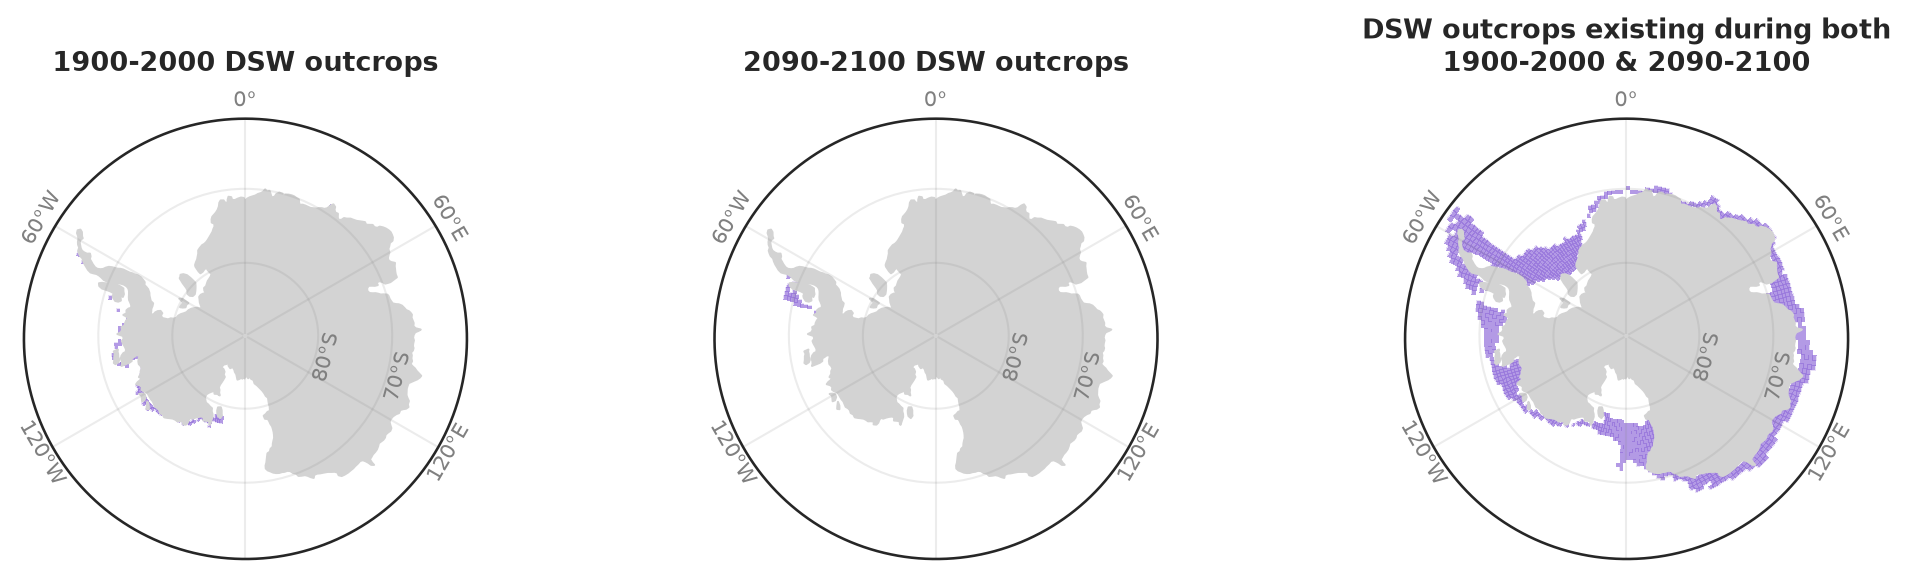

In [12]:
reference_period = '1900-2000'
pert_period = '2090-2100'
times_list = [daterange2tuple(reference_period), daterange2tuple(pert_period)]
nt = len(times_list)

base = ListedColormap(['white','mediumpurple'])
colors = base(np.linspace(0, 1, base.N))
colors[:, -1] = 0.7        # set all alphas to
cmap = ListedColormap(colors)

regions = ["D_f_minus_g", "D_g_minus_f", "D_intersect"]
nr = len(regions)

fig, ax = plt.subplots(1, nr, figsize = (14, 4),
                        subplot_kw={'projection': ccrs.SouthPolarStereo()})
[a.set_extent([-180, 180, -90, -60], ccrs.PlateCarree()) for a in ax.flatten()]

for (i, region) in enumerate(regions):
    cm = plot_antarctic(1.0 * ds_diff_decomp[region], ax[i], 
                        cmap = cmap, norm = None, mask_threshold = -np.inf)
        


ax[0].set_title('-'.join(list(map(str, times_list[0]))) + " DSW outcrops", 
             fontweight = "bold", fontsize = 13, ha='center',y = 1.08)

ax[1].set_title('-'.join(list(map(str, times_list[1]))) + " DSW outcrops", 
             fontweight = "bold", fontsize = 13, ha='center',y = 1.08)


ax[2].set_title("DSW outcrops existing during both\n" + '-'.join(list(map(str, times_list[0]))) + " & " + '-'.join(list(map(str, times_list[1]))), 
             fontweight = "bold", fontsize = 13, ha='center',y = 1.08)

fig.tight_layout()

fig.savefig("plots/S2.DSW_outcrops_Spatial_Differences.png", dpi = 250, bbox_inches = "tight")

In [13]:
ds_sfc_props = xr.open_mfdataset(outputdir(f"Southern_Ocean_50S_Monthly_Surface_Fluxes_And_Properties.zarr"))
# Define your custom seasons (example: tropical wet/dry seasons)
def custom_seasons(month):
    """Define custom seasons based on month"""
    if month in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:  # all months
        return 'winter'
    else:
        return 'not_winter'

# Apply to your data
season_labels = xr.apply_ufunc(
    custom_seasons, 
    ds_sfc_props.time.dt.month,
    vectorize=True,
    dask='allowed'
)

# Add as coordinate
ds_sfc_props_with_seasons = ds_sfc_props.assign_coords(custom_season=('time', season_labels.data))

ds_sfc_props_winter_data = ds_sfc_props_with_seasons.where(ds_sfc_props_with_seasons.custom_season == 'winter', drop=True)
ds_sfc_props_winter_data["sivol"] = ds_sfc_props_winter_data["sithick"] * ds_sfc_props_winter_data["siconc"] * ds_sfc_props_winter_data["areacello"]
ds_sfc_props_winter_yearly_averages = ds_sfc_props_winter_data.groupby('time.year').mean('time').compute()

In [14]:
# ds_sfc_sigma_geq = ds_sfc_props_winter_yearly_averages.sel(exp = "forced")
ds_sfc_props_mod = 1 * get_sigma2_at_surface(ds_sfc_props_winter_yearly_averages, keep_vars = False).where(ds_sfc_props_winter_yearly_averages.wet > 0.0)
ds_sfc_props_mod["beta"] = gsw.beta(ds_sfc_props_mod.sos, ds_sfc_props_mod.tos, 2000.0)
ds_sfc_props_mod["alpha"] = gsw.alpha(ds_sfc_props_mod.sos, ds_sfc_props_mod.tos, 2000.0)

ds_sfc_sigma_geq = 1 * ds_sfc_props_mod
# ds_sfc_sigma_geq_thermo = get_sigma2_at_surface(ds_sfc_sigma_geq, keep_vars = False)

In [15]:
def area_weighted_average(da, mask, x="xh", y="yh", area="areacello"):
    weights = da[area].where((mask > 0) & da.notnull())
    return (
        (da * weights).sum([x, y])
        / weights.sum([x, y])
    )

In [16]:
average_period = lambda ds, period_slice: ds.sel(year = period_slice).mean("year")
get_baselines = lambda ds, var: average_period(ds[var], slice(reference_period[0], reference_period[1]))
get_anomaly = lambda ds, var: average_period(ds[var], slice(pert_period[0], pert_period[1])) - ds[f"{var}_baseline"]
get_anomaly_ts = lambda ds, var: ds[var] - ds[f"{var}_baseline"]


ds_sigma_sfc_decomp = ds_sfc_sigma_geq[["rho2", "tos", "sos"]].sel(exp = "forced")
ds_sigma_sfc_decomp["rho2_baseline"] = get_baselines(ds_sigma_sfc_decomp, "rho2")
ds_sigma_sfc_decomp["tos_baseline"] = get_baselines(ds_sigma_sfc_decomp, "tos")
ds_sigma_sfc_decomp["sos_baseline"] = get_baselines(ds_sigma_sfc_decomp, "sos")


p_ref = 2000 #2000 dbar reference pressure 

# Calculate thermal expansion coefficient alpha (1/K) at reference pressure
ds_sigma_sfc_decomp['alpha_baseline'] = xr.apply_ufunc(
    gsw.alpha, ds_sigma_sfc_decomp["sos_baseline"], ds_sigma_sfc_decomp["tos_baseline"], p_ref, dask="parallelized"
)

# Calculate the haline contraction coefficient beta (kg/g) at reference pressure
ds_sigma_sfc_decomp['beta_baseline'] = xr.apply_ufunc(
    gsw.beta, ds_sigma_sfc_decomp["sos_baseline"], ds_sigma_sfc_decomp["tos_baseline"], p_ref, dask="parallelized"
)


ds_sigma_sfc_decomp["rho2_anomaly"] = get_anomaly_ts(ds_sigma_sfc_decomp, "rho2")
ds_sigma_sfc_decomp["tos_anomaly"] = get_anomaly_ts(ds_sigma_sfc_decomp, "tos")
ds_sigma_sfc_decomp["sos_anomaly"] = get_anomaly_ts(ds_sigma_sfc_decomp, "sos")

# rho0 = ds_sigma_sfc_decomp["rho2_baseline"] + 1000  #could eb comething else? 
rho0 = 1035
ds_sigma_sfc_decomp["rho2_anomaly_ct_contrib"] = -rho0 * ds_sigma_sfc_decomp['alpha_baseline'] * ds_sigma_sfc_decomp["tos_anomaly"]
ds_sigma_sfc_decomp["rho2_anomaly_sa_contrib"] =  rho0 * ds_sigma_sfc_decomp['beta_baseline']  * ds_sigma_sfc_decomp["sos_anomaly"]

ds_sigma_sfc_decomp["rho2_anomaly_recon"] = ds_sigma_sfc_decomp["rho2_anomaly_ct_contrib"] + ds_sigma_sfc_decomp["rho2_anomaly_sa_contrib"]

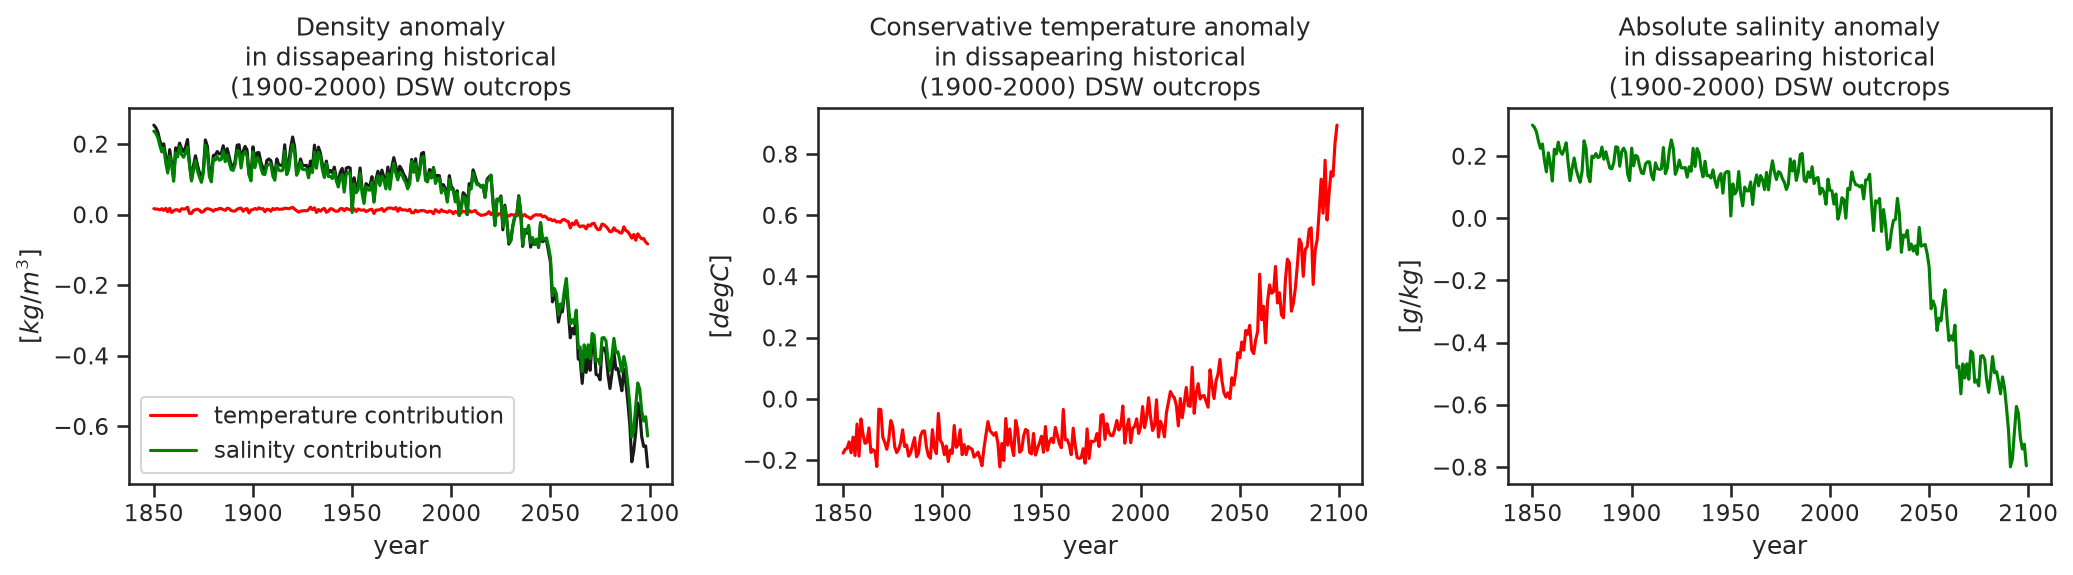

In [17]:
region_of_interest = ds_diff_decomp["D_f"]
# dens_region = density_title.replace('(', '').replace(')', '').replace('\\mathbf', '')

fig, axes = plt.subplots(1, 3, figsize = (14, 4))
temp_color = "red"
sal_color = "green"
ax = axes[0]
area_weighted_average(ds_sigma_sfc_decomp["rho2_anomaly"], region_of_interest).plot(ax=ax, c= "k")

ct_contrib = ds_sigma_sfc_decomp["rho2_anomaly_ct_contrib"]# + ds_sigma_sfc_decomp["rho2_baseline"]
area_weighted_average(ct_contrib, region_of_interest).plot(ax=ax, label= "temperature contribution", c = temp_color)

sa_contrib = ds_sigma_sfc_decomp["rho2_anomaly_sa_contrib"]# + ds_sigma_sfc_decomp["rho2_baseline"]

area_weighted_average(sa_contrib, region_of_interest).plot(ax=ax, label= "salinity contribution", c = sal_color)
ax.legend()
ax.set_title(f"Density anomaly\nin dissapearing historical\n({reference_period}) DSW outcrops")
ax.set_ylabel(r"$[kg/m^3]$")

ax = axes[1]
# plot temperature
temp_line = area_weighted_average(ds_sigma_sfc_decomp["tos_anomaly"], region_of_interest).plot(ax=ax, color=temp_color)
# label and color the left y‑axis for temperature
ax.set_title(f"Conservative temperature anomaly\nin dissapearing historical\n({reference_period}) DSW outcrops")
ax.set_ylabel(r"$[deg C]$")

# twin for salinity
axt = axes[2]
salt_line = area_weighted_average(ds_sigma_sfc_decomp["sos_anomaly"], region_of_interest).plot(ax=axt, color=sal_color)
# label and color the right y‑axis for salinity
axt.set_title(f"Absolute salinity anomaly\nin dissapearing historical\n({reference_period}) DSW outcrops")
axt.set_ylabel(r"$ [g/kg]$")

fig.tight_layout()

fig.savefig("plots/S3.Dissapearing_Outcrop_Thermodynamics.png", dpi = 250, bbox_inches = "tight")

In [18]:
ds_sfc_sigma_geq_thermo_fluxes = 1 * ds_sfc_sigma_geq[["fsitherm", "hfsso", "siconc", "sithick", "sivol"]].sel(exp = "forced")

In [19]:
def preprocess_giomas(ds):
    year = int(ds["year"])

    time = np.array(
        [np.datetime64(f"{year}-{month:02d}-01")
         for month in ds["month"].values]
    )

    ds = ds.assign_coords(
        time=("n", time),
        lon_scaler=ds["lon_scaler"],
        lat_scaler=ds["lat_scaler"],
        z=ds["z"],
        dz=ds["dz"],
        dxt = ds["dxt"], 
        dyt = ds["dyt"], 
        darea = ds["dxt"] * 1e3 *  ds["dyt"] * 1e3, 
        # kmt = ds["kmt"], 
    )
    ds = ds.drop_vars("kmt")

    ds = ds.swap_dims({"n": "time"})
    ds = ds.drop_vars(["year", "month"])

    return ds.rename({"lon_scaler":"lon", "lat_scaler":"lat"})
    
giomass = xr.open_mfdataset(
    "GIOMAS/*",
    preprocess=preprocess_giomas,
    combine="by_coords")

giomass["area"] = giomass["area"].where((giomass["area"] < 9999.9) * (giomass["area"] > 0.0))
giomass["heff"] = giomass["heff"].where((giomass["heff"] < 9999.9) * (giomass["heff"] > 0.0))
giomass["sivol"] = giomass["darea"] * giomass["heff"] 
giomass = giomass.groupby("time.year").mean("time").compute()

OSError: no files to open

In [ ]:
averaging_mask = xr.where(ds_diff_decomp["D_intersect"] > 0, 1, 0)
averaging_mask = averaging_mask.where(averaging_mask > 0.0).bfill("yh").interpolate_na(dim = "xh", method = "nearest", max_gap = 5)
averaging_mask = averaging_mask.fillna(0.0)

In [ ]:
noaa_si_conc = xr.open_dataset("NOAA_SI_Conc.nc")
noaa_si_conc["cdr_seaice_conc_monthly_latlon"] = noaa_si_conc["cdr_seaice_conc_monthly_latlon"].where(noaa_si_conc["cdr_seaice_conc_monthly_latlon"]  > 0.0)
regridder = xe.Regridder(averaging_mask, noaa_si_conc,
    method="nearest_s2d",
    periodic=True,
                        
)

noaa_mask = regridder(averaging_mask)

noaa_si_conc["cdr_seaice_conc_monthly_latlon"].isel(year = 0).plot.contourf()
noaa_mask.plot.contour(colors = "red")

In [ ]:
regridder = xe.Regridder(averaging_mask, giomass,
    method="nearest_s2d",
    periodic=True,
)

giomass_mask = regridder(averaging_mask)
giomass["area"].isel(year = 0).plot.contourf()
giomass_mask.plot.contour(colors = "red")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (20, 5))
ds_sfc_sigma_geq_thermo_fluxes["sivol"].mean("year").plot(ax = ax[0])
giomass["sivol"].sel(year = 2020).plot(ax = ax[1])

In [ ]:
fig, axes = plt.subplots(2, 2, figsize = (10.0, 7.0))

ax = axes[0, 0]
#convert from kg/m^2/s -> m/year. operation is flux * seconds in  a year / density of seawater
area_weighted_average(-ds_sfc_sigma_geq_thermo_fluxes["fsitherm"].sum("sigma2_l") * 3.154e+7 / 1000, averaging_mask).plot(ax=ax, c= "k")
ax.set_title("")
ax.set_title(f"(a) Upward sea-ice freshwater flux", fontweight = "bold", loc='left')
ax.set_ylabel(r"[m yr$^{-1}$]")

ax = axes[0, 1]
area_weighted_average(100 * ds_sfc_sigma_geq_thermo_fluxes["siconc"], averaging_mask).plot(ax=ax, c= "k")

area_weighted_average(100 * giomass["area"].sel(year = slice(None, 2025)), giomass_mask, 
                     x = "j", y = "i", area = "darea").plot(ax=ax, c= "#158EEB")
# area_weighted_average(100 * envisat_cryosat["ice_concentration"].sel(year = slice(None, 2025)), envisat_cryosat_mask, 
#                      x = "x", y = "y", area = "areacello").plot(ax=ax, c= "#6adb56")
area_weighted_average(100 * noaa_si_conc["cdr_seaice_conc_monthly_latlon"].sel(year = slice(None, 2024)), noaa_mask, 
                     x = "x", y = "y", area = "areacello").plot(ax=ax, c= "#EB7215")
ax.set_title("")
ax.set_title(f"(b) Sea ice concentration", fontweight = "bold", loc='left')
ax.set_ylabel(r"[$\%$]")

ax.text( 1985, 62, "NOAA\nNSIDC", c= "#EB7215", fontweight = "bold", fontsize = 12)
ax.text( 1915, 70, "GIOMAS", c= "#158EEB", fontweight = "bold", fontsize = 12)
# ax.text( 2020, 79, "Bocquet et. al\n2024", c= "#6adb56", fontweight = "bold", fontsize = 12)

ax = axes[1, 0]
area_weighted_average(1e-9 * ds_sfc_sigma_geq_thermo_fluxes["sivol"], ds_diff_decomp["D_intersect"]).plot(ax=ax, c= "k")
area_weighted_average(1e-9 * giomass["sivol"].sel(year = slice(None, 2024)), giomass_mask, 
                     x = "j", y = "i", area = "darea").plot(ax=ax, c= "#158EEB")
# area_weighted_average(2e-8 * envisat_cryosat["sea_ice_volume"], envisat_cryosat_mask, 
#                      x = "x", y = "y", area = "areacello").plot(ax=ax, c= "#6adb56")
ax.set_title("")
ax.set_title(f"(c) Sea ice volume", fontweight = "bold", loc='left')
ax.set_ylabel(r"[km$^3$]")
ax.text( 1915, 1.5, "GIOMAS", c= "#158EEB", fontweight = "bold", fontsize = 12)

ax = axes[1, 1]
area_weighted_average(-ds_sfc_sigma_geq_thermo_fluxes["hfsso"].sum("sigma2_l"), averaging_mask).plot(ax=ax, c= "k")
ax.set_title("")
ax.set_title(f"(d) Upward sensible heat flux", fontweight = "bold", loc='left')
ax.set_ylabel( r"[W m$^{-2}$]")

# fig.suptitle(f"Yearly-averaged quantities in DSW outcrops", fontweight = "bold")
fig.tight_layout()
[a.grid(alpha = 0.2) for a in axes.flatten()]
fig.savefig("plots/5.Remaining_DSW_Outcrop_Fluxes.png", dpi = 350, bbox_inches = "tight")

In [ ]:
def print_averages(ds): 
    x1 = np.round(ds.sel(year = slice(1900, 2000)).mean("year").values.item(), decimals = 2)
    x2 =  np.round(ds.sel(year = slice(2090, 2100)).mean("year").values.item(), decimals = 2)
    print("1900-2000: ", x1)
    print("2090-2100: ",x2)
    print("relative decrease: ", 100 * ((x2 - x1) / x1))

print("fsitherm")
print_averages(area_weighted_average(-ds_sfc_sigma_geq_thermo_fluxes["fsitherm"].sum("sigma2_l") * 3.154e+7 / 1000, averaging_mask))
print("siconc")
print_averages(area_weighted_average(100 * ds_sfc_sigma_geq_thermo_fluxes["siconc"], averaging_mask))
print("sivol")
print_averages(area_weighted_average(1e-9 * ds_sfc_sigma_geq_thermo_fluxes["sivol"], ds_diff_decomp["D_intersect"]))
print("hfsso")
print_averages(area_weighted_average(-ds_sfc_sigma_geq_thermo_fluxes["hfsso"].sum("sigma2_l"), averaging_mask))

In [ ]:
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import matplotlib.colors as mcolors

cmap = cmo.balance
boundaries = 1e-12 * np.arange(-10, 10 + 0.1, 1)
boundaries[np.abs(boundaries) < 1e-16] = 0
norm = BoundaryNorm(boundaries, cmap.N)

In [ ]:
datafiles = glob.glob(datadir("budget_sigma2_v1.2.0/CM4Xp125*"))[1:2]
mask_ds = xr.open_mfdataset(datafiles, engine = "zarr")

shelf_mask = (
    (mask_ds['geolat'] <= -50.0) * 
(mask_ds["deptho"].fillna(0.0) <= 1001.0))

grid = CM4Xutils.ds_to_grid(mask_ds)
regions = MaskRegions(shelf_mask, grid).region_dict
antarctic = regions[0] #there are more in this list if there are multiple contours 
region_mask = GriddedRegion("antarctic", antarctic.lons_c, antarctic.lats_c, grid, 
                       ij=(antarctic.i_c, antarctic.j_c)).mask

In [ ]:
def make_center_extended_cmap(
    levels,
    cmap_name="RdBu_r",
    center_value=0.0,
    zero_color=cmo.balance(0.5),):
    levels = np.asarray(levels)

    base = plt.get_cmap(cmap_name)
    colors = base(np.linspace(0, 1, len(levels) - 1))

    if zero_color is None:
        zero_color = base(0.5)
    else:
        zero_color = mcolors.to_rgba(zero_color)

    center_matches = np.where(np.isclose(levels, center_value))[0]
    if len(center_matches) == 0:
        raise ValueError(f"center_value={center_value} must appear in levels.")

    center_idx = center_matches[0]
    if center_idx == 0 or center_idx == len(levels) - 1:
        raise ValueError("center_value cannot be the first or last level.")

    colors[center_idx - 1:center_idx + 1] = zero_color

    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(levels, cmap.N)

    return cmap, norm
    
ds_sfc_props_forced_anomaly = ds_sfc_props_mod.sel(exp = "forced").sum("sigma2_l") 
ds_sfc_props_baseline = ds_sfc_props_mod.sel(exp = "control").sum("sigma2_l").mean("year")
ds_sfc_props_forced_anomaly = ds_sfc_props_forced_anomaly - ds_sfc_props_baseline


year_ranges = [(2001, 2010), (2021, 2030), (2041, 2050)]

sea_ice_anom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "sea_ice_anom",
    ["#551a55", "#cc4c5a", "#f3c884", "#f0f0f0",
     "#c7e5e3", "#4785b7", "#29284f"]
)

plot_specs = [
    {
        "name": "Sea ice\nconcentration",
        "data": 100 * ds_sfc_props_forced_anomaly["siconc"],
        "label": "[%]",
        "levels": np.arange(-15, 15.01, 1.5),
        "ticks": np.arange(-15, 16, 3),
        "cmap": sea_ice_anom_cmap,
    },
    {
        "name": "Sea ice thickness",
        "data": ds_sfc_props_forced_anomaly["sivol"] / ds_sfc_props_forced_anomaly["areacello"],
        "label": "[m]",
        "levels": np.arange(-.50, .5 + 1e-16, 0.05),
        "ticks": np.arange(-.50, 0.51, 0.2),
        "cmap": sea_ice_anom_cmap,
    },
    {
        "name": "Downward sea-ice\nfreshwater flux",
        "data": ds_sfc_props_forced_anomaly["fsitherm"] * 3.154e+7 / 1000, #convert to meters per year
        "label": r"[m yr$^{-1}$]",
        "levels": np.arange(-10, 10 + 1e-16, 1),
        "ticks": np.arange(-10, 10 + 1e-16, 2),
        "cmap": cmo.delta_r,
    },
    
    {
        "name": "Downward sensible\nheat flux",
        "data": ds_sfc_props_forced_anomaly["hfsso"],
        "label": r"[W m$^{-2}$]",
        "levels": np.arange(-50, 50 + 1e-16, 5),
        "ticks": np.arange(-50, 50 + 1e-16, 10),
        "cmap": cmo.balance,
    },
    {
        "name": "Zonal wind stress",
        "data": ds_sfc_props_forced_anomaly["taux"],
        "label": r"[N m$^{-2}$]",
        "levels": np.arange(-0.04, 0.04 + 1e-16, 0.005),
        "ticks": np.arange(-0.04, 0.04 + 1e-16, 0.01),
        "cmap": cmo.curl,
    },
    {
        "name": "Sea surface\ntemperature",
        "data": ds_sfc_props_forced_anomaly["tos"],
        "label": "[deg C]",
        "levels": np.arange(-1, 1+ 1e-16, 0.1),
        "ticks": np.arange(-1, 1 + 1e-16, 0.2),
        "cmap": "RdBu_r",
    },
    {
        "name": "Sea surface\nsalinity",
        "data": ds_sfc_props_forced_anomaly["sos"],
        "label": "PSU]",
        "levels": np.arange(-0.4, 0.4 + 1e-16, 0.05),
        "ticks":  np.arange(-0.4, 0.4 + 1e-16, 0.1),
        "cmap": cmo.delta,
    },
]

nrows = len(plot_specs)
ncols = len(year_ranges)

fig, ax = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.2 * nrows),
                       subplot_kw={"projection": ccrs.SouthPolarStereo()},
                       constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.005, h_pad=0.02, wspace=0.005, hspace=0.02)

ax = np.atleast_2d(ax)

def get_panel_labels(n):
    import string
    # This slices the alphabet string to the length you need
    return list(string.ascii_lowercase[:n])

# Usage:
panel_labels = get_panel_labels(ncols * nrows)

k = -1
for row, spec in enumerate(plot_specs):
    da = spec["data"]
    label = spec["label"]
    levels = spec["levels"]
    ticks = spec["ticks"]
    cmap_name = spec["cmap"]
    name = spec["name"]

    cmap, norm = make_center_extended_cmap(levels, cmap_name=cmap_name)

    for col, year_range in enumerate(year_ranges):
        k+=1
        start_year, end_year = year_range
        this_ax = ax[row, col]

        this_ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

        data_decade = da.sel(year=slice(start_year, end_year)).mean("year")

        cm = plot_antarctic(data_decade, this_ax, cmap=cmap, norm=norm, mask_threshold=-np.inf, draw_labels = True)
        
        if row == 0:
            this_ax.set_title(f"{start_year}–{end_year}", pad=9, fontweight = "bold", fontsize = 16, y = 1.04)
        if col == 0:
            ax[row, col].text(
                        -0.12, 0.5, name,
                        transform=ax[row, 0].transAxes,
                        rotation=90,
                        va="center",
                        ha="center",
                        fontsize=16,
                        fontweight="bold",
                        )
        # if row == 0 and col == 0:
            # print("mask")
        ax[row, col].contour(region_mask.geolon, region_mask.geolat, 1.0 * region_mask, 
                             levels = [0.5], transform=ccrs.PlateCarree(), 
                             colors = "white", zorder = 100)

        this_ax.text(
            0.48,
            0.53,
            panel_labels[k],
            transform=this_ax.transAxes,
            ha="left",
            va="top",
            fontsize=16,
            fontweight="bold",
            zorder=300,
        )
    
    cbar = fig.colorbar(cm, ax=ax[row, :], orientation="vertical",
                        fraction=0.011, pad=0.02, extend="both", ticks=ticks, label = label)

# One shared period label for the whole figure.
fig.suptitle(
    "Historical/SSP5-8.5 anomalies relative to piControl climatologies",
    fontsize=19,
    fontweight="bold",
    y=1.03,
)

fig.savefig("plots/S4.Surface_Flux_anomalies.png", dpi = 350, bbox_inches = "tight")

In [ ]:
baseline_plot_specs = [
    {
        "name": "siconc",
        "data": 100 * ds_sfc_props_baseline["siconc"],
        "label": "Sea ice concentration [%]",
        "levels": np.arange(0, 100.01, 10),
        "ticks": np.arange(0, 101, 20),
        "cmap": cmo.ice,
        "extend": "max",
    },
    {
        "name": "Sea ice thickness",
        "data": ds_sfc_props_baseline["sithick"],
        "label": "Sea ice thickness [m]",
        "levels": np.arange(0, 2.1, 0.1),
        "ticks": np.arange(0, 2.1, 0.5),
        "cmap": cmo.ice,
    },
    {
        "name": "fsitherm",
        "data": ds_sfc_props_baseline["fsitherm"] * 3.154e+7 / 1000,
        "label": "Downward sea-ice freshwater\nflux " + r"[m yr$^{-1}$]",
        "levels": np.arange(-12, 12.1 + 1e-16, 1.5),
        "ticks": np.arange(-12, 12.1 + 1e-16, 3),
        "cmap": cmo.delta_r,
        "extend": "both",
    },
    {
        "name": "hfsso",
        "data": ds_sfc_props_baseline["hfsso"],
        "label": "Downward sensible heat\nflux " + r"[W m$^{-2}$]",
        "levels": np.arange(-210, 210.1 + 1e-16, 35),
        "ticks": np.arange(-210, 210.1 + 1e-16, 70),
        "cmap": cmo.balance,
        "extend": "both",
    },
    {
        "name": "taux",
        "data": ds_sfc_props_baseline["taux"],
        "label": "Zonal wind stress " + r"[N m$^{-2}$]",
        "levels": np.arange(-0.12, 0.12 + 1e-16, 0.02),
        "ticks": np.arange(-0.12, 0.12 + 1e-16, 0.04),
        "cmap": cmo.curl,
        "extend": "both",
    },
    {
        "name": "tos",
        "data": ds_sfc_props_baseline["tos"],
        "label": "Sea surface\ntemperature [deg C]",
        "levels": np.arange(-2, 2.1, 0.25),
        "ticks": np.arange(-2, 2.1, 0.5),
        "cmap": "RdBu_r",
        "extend": "both",
    },
    {
        "name": "sos",
        "data": ds_sfc_props_baseline["sos"],
        "label": "Sea surface\nsalinity [PSU]",
        "levels": np.arange(32, 35 + 1e-16, 0.25),
        "ticks": np.arange(32, 35 + 1e-16, 0.5),
        "cmap": cmo.delta_r,
        "extend": "both",
    },
]

nplots = len(baseline_plot_specs)
ncols = 3
nrows = int(np.ceil(nplots / ncols))

fig, ax = plt.subplots(
    nrows,
    ncols,
    figsize=(4.0 * ncols, 3.8 * nrows),
    subplot_kw={"projection": ccrs.SouthPolarStereo()},
    constrained_layout=True,
    squeeze=False,
)

panel_labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
panel_labels = [letter.lower() for letter in panel_labels]

for i, spec in enumerate(baseline_plot_specs):
    row, col = divmod(i, ncols)
    this_ax = ax[row, col]

    da = spec["data"]
    levels = spec["levels"]
    ticks = spec["ticks"]
    label = spec["label"]
    extend = spec.get("extend", "both")
    cmap_in = spec["cmap"]

    this_ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

    if np.any(np.isclose(levels, 0.0)) and levels[0] < 0 < levels[-1]:
        cmap, norm = make_center_extended_cmap(levels, cmap_name=cmap_in)
    else:
        cmap = plt.get_cmap(cmap_in) if isinstance(cmap_in, str) else cmap_in
        norm = mcolors.BoundaryNorm(levels, cmap.N)

    cm = plot_antarctic(
        da,
        this_ax,
        cmap=cmap,
        norm=norm,
        mask_threshold=-np.inf,
        draw_labels=True,
)
    this_ax.contour(region_mask.geolon, region_mask.geolat, 1.0 * region_mask, 
                         levels = [0.5], transform=ccrs.PlateCarree(), 
                         colors = "white", zorder = 100)
    this_ax.text(
        0.48,
        0.53,
        panel_labels[i],
        transform=this_ax.transAxes,
        ha="left",
        va="top",
        fontsize=16,
        fontweight="bold",
        zorder=300,
    )

    fig.colorbar(
        cm,
        ax=this_ax,
        orientation="horizontal",
        fraction=0.06,
        pad=0.035,
        extend=extend,
        ticks=ticks,
        label=label,
    )

for j in range(nplots, nrows * ncols):
    row, col = divmod(j, ncols)
    ax[row, col].set_visible(False)

fig.suptitle(
    "piControl climatologies",
    fontsize=19,
    fontweight="bold",
    y=1.03,
)

fig.savefig(
    "plots/S5.Surface_Flux_and_Surface_Props_baselines.png",
    dpi=350,
    bbox_inches="tight",
)